# Steady-State PWM Technical Report

## Methods

Steady-state PWM behavior was evaluated by applying DC input voltages from 0 to 3 V in 0.5 V increments to the ADC input (AIN0). For each voltage, three oscilloscope captures of the PWM output were collected and exported as CSV files. The analysis, implemented in Python , extracted time and voltage data and estimated high and low levels using the 95th and 5th percentiles. A midpoint threshold was used to classify the signal into high and low states.

Because the LED is active-low, duty cycle was defined as the fraction of time the signal was in the low state. Edge detection was applied to identify low pulses, from which pulse widths and periods were computed after filtering out short-duration noise. Frequency was calculated as the inverse of the average period when sufficient pulses were present. For saturated cases (0 V and 3 V), where switching was absent or negligible, duty cycle was assigned based on the signal level and frequency was not reported. Mean values and 95% confidence intervals were computed across trials, and linear regression was performed against the ideal relationship of 100 * Vin/3.

## Results

/Users/nikhilmethi/Duke/BME554/duke-bme554-ecg-temp-ble-lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/nikhilmethi/Duke/BME554/duke-bme554-ecg-temp-ble-lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


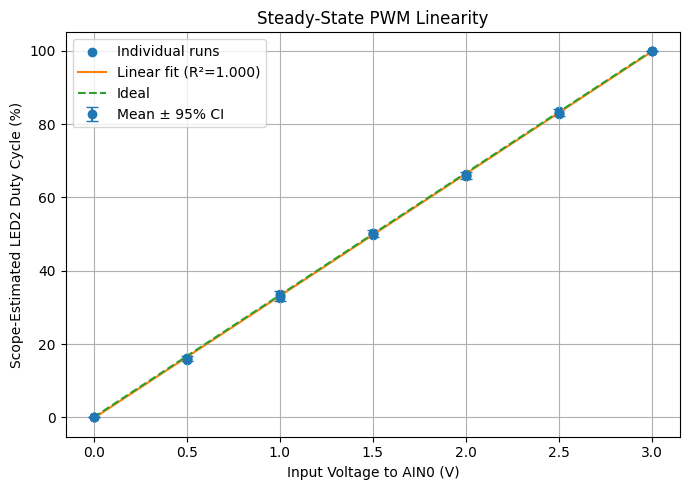

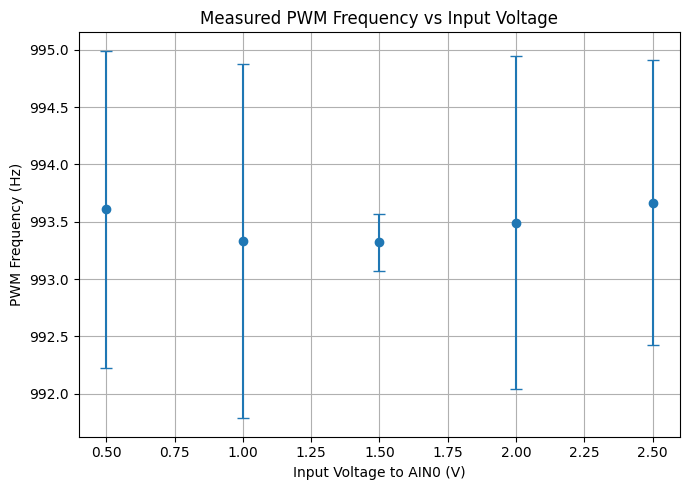

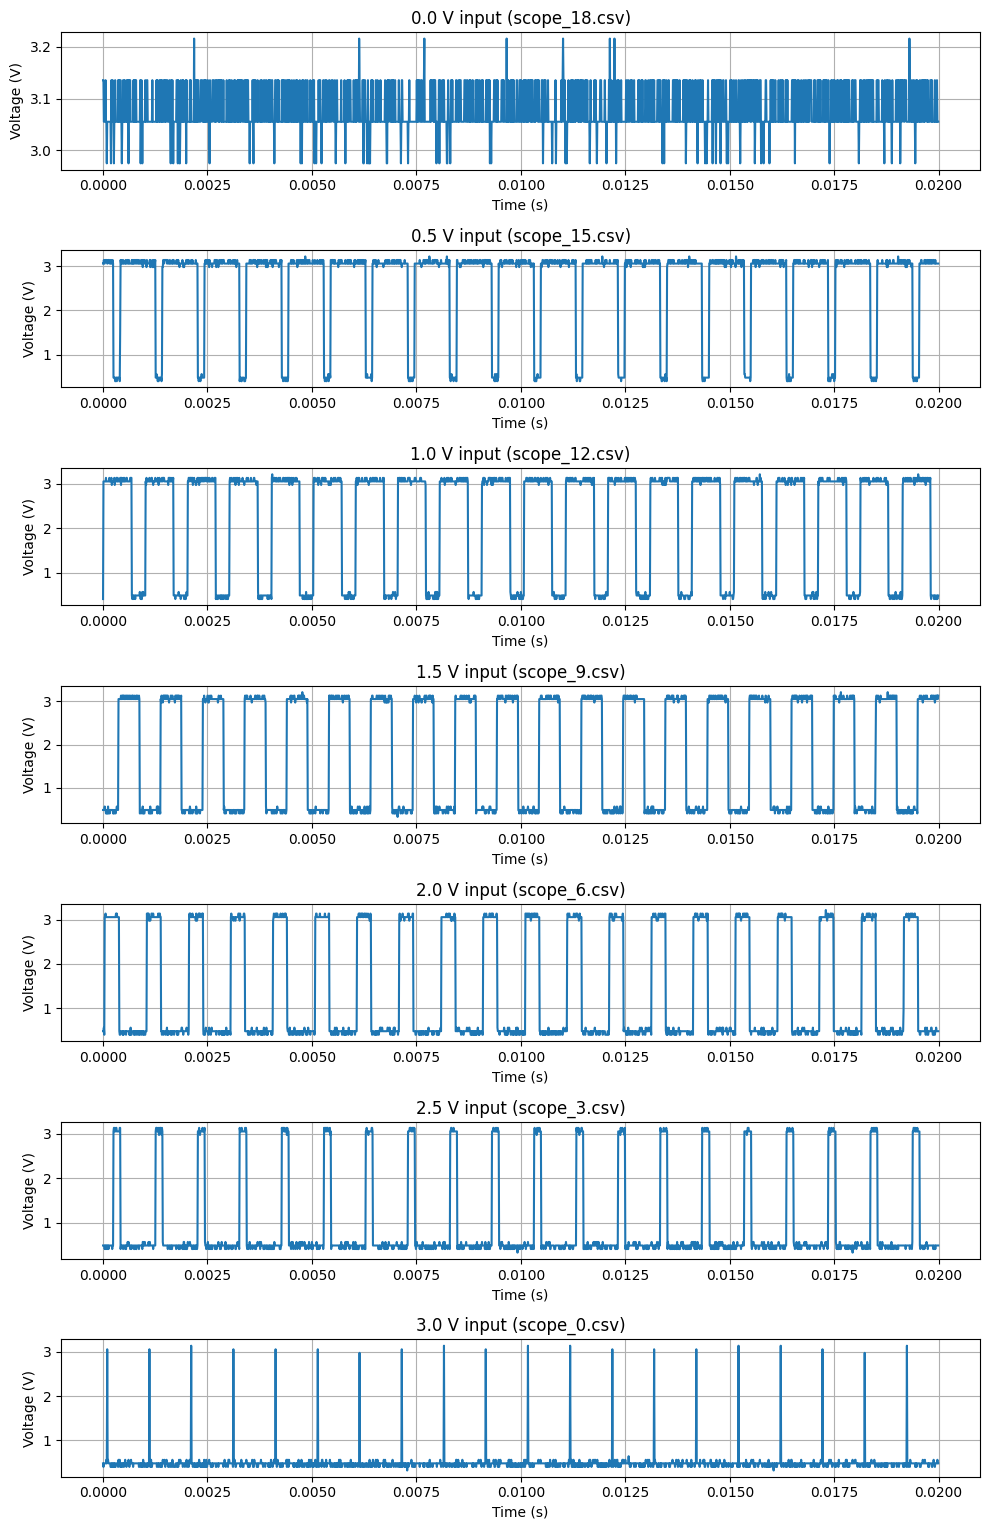

Slope = 33.3560 %/V
Intercept = -0.2696 %
R² = 0.9999
p-value = 1.6285e-11


,input_voltage_v,n,scope_duty_mean_pct,scope_duty_95ci_pct,scope_freq_mean_hz,scope_freq_95ci_hz,ideal_duty_pct
0,0.0,3,0.000000,0.000000,NaN,0.000000,0.000000
1,0.5,3,16.016667,0.586979,993.608575,1.383493,16.666667
2,1.0,3,33.150000,1.432424,993.329656,1.544258,33.333333
3,1.5,3,50.100000,0.970087,993.319786,0.248252,50.000000
4,2.0,3,66.000000,0.869448,993.493140,1.449483,66.666667
5,2.5,3,83.083333,1.011606,993.666273,1.242560,83.333333
6,3.0,3,100.000000,0.000000,NaN,0.000000,100.000000


In [35]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "SS_data"

FILE_TO_VOLTAGE = {
    0: 3.0, 1: 3.0, 2: 3.0,
    3: 2.5, 4: 2.5, 5: 2.5,
    6: 2.0, 7: 2.0, 8: 2.0,
    9: 1.5, 10: 1.5, 11: 1.5,
    12: 1.0, 13: 1.0, 14: 1.0,
    15: 0.5, 16: 0.5, 17: 0.5,
    18: 0.0, 19: 0.0, 20: 0.0,
}

def extract_num(path):
    return int(re.search(r"scope_(\d+)\.csv$", path.name, re.I).group(1))

def load_scope_csv(path):
    df = pd.read_csv(path, header=None)
    t = pd.to_numeric(df.iloc[2:, 0], errors="coerce").dropna().to_numpy(float)
    v = pd.to_numeric(df.iloc[2:, 1], errors="coerce").dropna().to_numpy(float)
    n = min(len(t), len(v))
    return t[:n] - t[0], v[:n]

def measure_pwm(t, v):
    t = np.asarray(t, dtype=float)
    v = np.asarray(v, dtype=float)

    if len(t) < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0

    v_high = np.percentile(v, 95)  # the HIGH rail (~3V)
    v_low_floor = np.percentile(v, 5)   # the LOW rail (~0.4V)

    # 0V input case: LED fully OFF → signal stays HIGH constantly (0% duty)
    if v_high - v_low_floor < 1.0:
        # Signal is flat — determine whether it's stuck high or stuck low
        if np.median(v) > 1.5:
            return 0.0, np.nan, np.median(v), np.nan, np.median(v), 0   # flat high → 0% duty
        else:
            return 100.0, np.nan, np.median(v), np.median(v), np.median(v), 0  # flat low → 100% duty

    threshold = 0.5 * (v_high + v_low_floor)

    # ACTIVE_LOW: LED is ON when signal is LOW
    # duty cycle = fraction of time signal is LOW
    is_low = v < threshold
    duty_pct = 100.0 * is_low.mean()

    edges = np.diff(is_low.astype(int))
    falling_edges = np.where(edges == 1)[0] + 1   # signal goes LOW (LED turns ON)
    rising_edges  = np.where(edges == -1)[0] + 1  # signal goes HIGH (LED turns OFF)

    # Ensure we start with a falling edge
    if len(rising_edges) and len(falling_edges) and rising_edges[0] < falling_edges[0]:
        rising_edges = rising_edges[1:]

    n_pairs = min(len(falling_edges), len(rising_edges))
    falling_edges = falling_edges[:n_pairs]
    rising_edges  = rising_edges[:n_pairs]

    valid = rising_edges > falling_edges
    falling_edges = falling_edges[valid]
    rising_edges  = rising_edges[valid]

    if len(falling_edges) < 2:
        return duty_pct, np.nan, threshold, v_low_floor, v_high, len(falling_edges)

    pulse_starts  = t[falling_edges]
    pulse_ends    = t[rising_edges]
    pulse_widths  = pulse_ends - pulse_starts

    dt = np.median(np.diff(t)) if len(t) > 1 else 0.0
    keep = pulse_widths > max(1.5 * dt, 0.0)
    pulse_starts  = pulse_starts[keep]
    pulse_widths  = pulse_widths[keep]

    if len(pulse_starts) < 2:
        return duty_pct, np.nan, threshold, v_low_floor, v_high, len(pulse_starts)

    periods = np.diff(pulse_starts)
    periods = periods[periods > 0]

    if len(periods) == 0:
        return duty_pct, np.nan, threshold, v_low_floor, v_high, len(pulse_starts)

    freq = 1.0 / np.mean(periods)

    return duty_pct, freq, threshold, v_low_floor, v_high, len(pulse_starts)

def mean_ci(x):
    x = pd.Series(x).dropna().to_numpy(float)
    mean = np.mean(x)
    ci = stats.t.ppf(0.975, len(x) - 1) * stats.sem(x) if len(x) > 1 else 0.0
    return mean, ci

rows = []
csv_files = sorted(DATA_DIR.glob("scope_*.csv"), key=extract_num)

for f in csv_files:
    num = extract_num(f)
    vin = FILE_TO_VOLTAGE[num]
    t, v = load_scope_csv(f)
    duty, freq, thr, vlo, vhi, npulses = measure_pwm(t, v)

    rows.append({
        "file_num": num,
        "csv_file": f.name,
        "input_voltage_v": vin,
        "scope_duty_pct": duty,
        "scope_freq_hz": freq,
        "threshold_v": thr,
        "low_v": vlo,
        "high_v": vhi,
        "n_pulses": npulses,
    })

results_df = pd.DataFrame(rows).sort_values("file_num").reset_index(drop=True)

summary_rows = []
for vin, grp in results_df.groupby("input_voltage_v", sort=True):
    duty_mean, duty_ci = mean_ci(grp["scope_duty_pct"])
    freq_mean, freq_ci = mean_ci(grp["scope_freq_hz"])
    summary_rows.append({
        "input_voltage_v": vin,
        "n": len(grp),
        "scope_duty_mean_pct": duty_mean,
        "scope_duty_95ci_pct": duty_ci,
        "scope_freq_mean_hz": freq_mean,
        "scope_freq_95ci_hz": freq_ci,
        "ideal_duty_pct": 100 * vin / 3.0,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("input_voltage_v").reset_index(drop=True)

x = summary_df["input_voltage_v"].to_numpy(float)
y = summary_df["scope_duty_mean_pct"].to_numpy(float)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

plt.figure(figsize=(7, 5))
plt.scatter(results_df["input_voltage_v"], results_df["scope_duty_pct"], label="Individual runs")
plt.errorbar(
    summary_df["input_voltage_v"],
    summary_df["scope_duty_mean_pct"],
    yerr=summary_df["scope_duty_95ci_pct"],
    fmt="o",
    capsize=4,
    label="Mean ± 95% CI"
)
xfit = np.linspace(0, 3, 200)
plt.plot(xfit, intercept + slope * xfit, label=f"Linear fit (R²={r_squared:.3f})")
plt.plot(xfit, 100 * xfit / 3.0, "--", label="Ideal")
plt.xlabel("Input Voltage to AIN0 (V)")
plt.ylabel("Scope-Estimated LED2 Duty Cycle (%)")
plt.title("Steady-State PWM Linearity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.errorbar(
    summary_df["input_voltage_v"],
    summary_df["scope_freq_mean_hz"],
    yerr=summary_df["scope_freq_95ci_hz"],
    fmt="o",
    capsize=4
)
plt.xlabel("Input Voltage to AIN0 (V)")
plt.ylabel("PWM Frequency (Hz)")
plt.title("Measured PWM Frequency vs Input Voltage")
plt.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(summary_df), 1, figsize=(10, 2.2 * len(summary_df)))
if len(summary_df) == 1:
    axes = [axes]

for ax, vin in zip(axes, summary_df["input_voltage_v"]):
    fname = results_df[results_df["input_voltage_v"] == vin].sort_values("file_num").iloc[0]["csv_file"]
    t, v = load_scope_csv(DATA_DIR / fname)
    ax.plot(t, v)
    ax.set_title(f"{vin:.1f} V input ({fname})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Voltage (V)")
    ax.grid(True)

plt.tight_layout()
plt.show()

print(f"Slope = {slope:.4f} %/V")
print(f"Intercept = {intercept:.4f} %")
print(f"R² = {r_squared:.4f}")
print(f"p-value = {p_value:.4e}")

summary_df

## Discussion

The measured duty cycle exhibits an almost perfectly linear dependence on input voltage, with a slope of 33.3560 %/V and intercept near zero (−0.2696 %), closely matching the ideal mapping. The very high R² value (0.9999) confirms excellent linearity. Across the 0.5–2.5 V range, measured values closely match theoretical expectations with minimal deviation and tight confidence intervals, indicating both accuracy and repeatability.

At the endpoints, the system behaves as expected: 0 V produces a constant high output (0% duty), and 3 V produces a nearly constant low output (100% duty). These cases required explicit handling in analysis due to the lack of detectable switching. The PWM frequency remains approximately constant at ~993 Hz for all intermediate voltages, consistent with the configured 1 ms period, with small deviations attributable to measurement resolution.

A key consideration was correctly interpreting the active-low signal; duty cycle corresponds to the low-state fraction, not the high-state fraction. Once polarity and edge cases were handled properly, the measured results aligned closely with theoretical behavior, validating both the embedded implementation and the analysis approach.